# 22c. Agent Memory — Lifecycle & Extraction

**Tier:** Agent Engineering
**Estimated time:** 55 minutes
**Prerequisites:** 22 (Context Engineering), 22b (Agent Memory Systems)
**Priority:** 🟡 Important — 22b gave agents a place to *store* memories; this adds the two things that make memory usable at scale: knowing which memories matter *now*, and getting memories *out of raw sessions* automatically. *If skipped, revisit when:* your memory store grows unbounded, stale facts crowd out relevant ones, or you're hand-writing every memory instead of extracting it.
**Source material:** OpenViking (`retrieve/memory_lifecycle.py` hotness scoring, `session/compressor_v2.py` + `session/memory/*` extraction, `benchmark/locomo` memory eval), https://github.com/volcengine/OpenViking

## What You'll Learn
- **Hotness scoring** — blend access frequency + recency decay into retrieval so hot memories surface and stale ones fade
- **Hot/cold tiers + eviction** — keep a bounded working set without losing recall of the long tail
- **Session memory extraction** — turn a raw transcript into *typed* structured memories (events, entities, preferences, experiences) with self/peer routing
- **Memory evaluation** — a LOCOMO-style recall test that measures whether the right memory actually comes back

## Why This Matters
Notebook 22b stored memories by key and recalled them by similarity — but every memory was equal and permanent, and you had to write each one by hand. Real memory systems don't work that way. Your brain keeps frequently-used memories vivid and lets the rest fade, and it extracts salient facts from experience automatically rather than filing each one consciously. OpenViking implements exactly this: a hotness score that decays over time, and an LLM extraction loop that mines typed memories out of each session. Without lifecycle, a memory store becomes a junk drawer; without extraction, it never fills itself.

## Vivid, fading, and forgotten

Think about your own memory. What you did an hour ago and keep referring to is **vivid** — instantly available. A detail from a project you touch daily stays **warm**. Something from a one-off conversation last year has **faded** — still recoverable with effort, but not top-of-mind. And most moments are simply **forgotten**, and that's healthy: a memory that kept everything at equal vividness would be useless.

Two capabilities turn 22b's flat keyed store into something that behaves like this:

1. **Lifecycle (hotness).** Each memory carries a **hotness** score built from two signals: how *often* it's accessed (frequency) and how *recently* (recency, via exponential time-decay with a half-life). We blend hotness with semantic similarity at recall time, so a slightly-less-similar-but-hot memory can beat a more-similar-but-stale one — and truly cold memories can be **evicted** to keep the working set bounded.

2. **Extraction.** You shouldn't hand-write `remember("user_timezone", "CET")` after every chat. An **extraction** step reads a raw session transcript and emits *typed* memory operations — **events** ("deployed v5.2 on Tuesday"), **entities** ("HC-400 controller"), **preferences** ("prefers metric units"), **experiences** ("rollback-on-fail worked"). Each op is **routed**: facts about the current user go to *self* memory; facts about a named other party go to that *peer's* space.

OpenViking's formula for hotness is simple and worth internalizing:

```
hotness = sigmoid(log1p(access_count)) × 0.5 ** (age / half_life)
```

frequency saturates (the 100th access matters less than the 2nd), and recency decays smoothly. Let's build it.

In [1]:
import os, re, json, math, time
from dataclasses import dataclass, field
from pathlib import Path
import numpy as np

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"
if HAS_ANTHROPIC:
    import anthropic
    _client = anthropic.Anthropic()
    print("Anthropic ready — LLM extraction path will run live.")
else:
    _client = None
    print("No ANTHROPIC_API_KEY — using the deterministic rule-based extractor (concept-identical).")

# Offline-safe embeddings (same pattern as notebooks 16b / 08): try MiniLM, else n-gram.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent

def _ngram_vec(text, dim=512):
    v = np.zeros(dim, dtype=np.float32)
    t = re.sub(r"\s+", " ", text.lower())
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def make_embedder():
    try:
        import sys as _sys; _sys.path.insert(0, str(REPO_ROOT))
        from ragkit.embeddings import embed
        _ = embed(["probe"])
        return "ragkit-MiniLM", (lambda xs: np.asarray(embed(list(xs)), dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return "ngram-fallback", (lambda xs: np.vstack([_ngram_vec(x) for x in xs]))

EMBED_KIND, embed_texts = make_embedder()
print("Embedder:", EMBED_KIND)

No ANTHROPIC_API_KEY — using the deterministic rule-based extractor (concept-identical).


(real embeddings unavailable: ProxyError; using n-gram fallback)
Embedder: ngram-fallback


## Part 1 — Hotness scoring (frequency × recency)

We simulate time with an explicit clock (`SIM_NOW`) so the demo is deterministic. Each memory tracks `access_count` and `updated_at`. `hotness_score` combines a **saturating** frequency term with an **exponential-decay** recency term. Then `recall_blended` ranks by `alpha × similarity + (1 - alpha) × hotness`, so recall is aware of *both* what you asked and what's been useful lately.

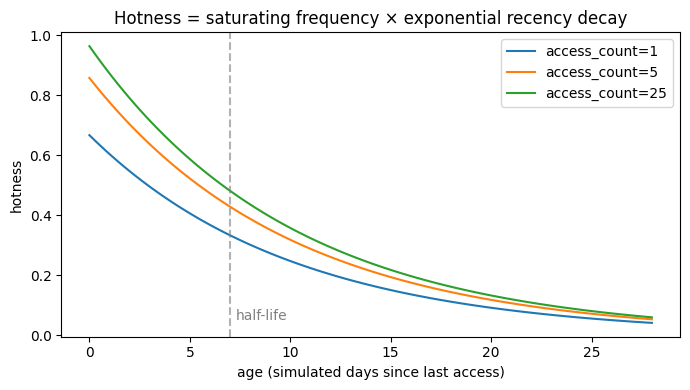

In [2]:
HALF_LIFE = 7.0    # in simulated "days": a memory loses half its recency weight every 7 days

def hotness_score(access_count, updated_at, now, half_life=HALF_LIFE):
    # Saturating frequency in (0,1): the 100th access matters less than the 2nd.
    freq = 1.0 / (1.0 + math.exp(-math.log1p(access_count)))
    # Exponential recency decay; age measured in the same units as `now`.
    age = max(0.0, now - updated_at)
    recency = 0.5 ** (age / half_life)
    return freq * recency

# Show the shape: hotness vs age for a few access counts.
%matplotlib inline
import matplotlib.pyplot as plt
ages = np.linspace(0, 28, 100)
fig, ax = plt.subplots(figsize=(7, 4))
for cnt in (1, 5, 25):
    ax.plot(ages, [hotness_score(cnt, 0, a) for a in ages], label=f"access_count={cnt}")
ax.axvline(HALF_LIFE, ls="--", color="gray", alpha=0.6)
ax.text(HALF_LIFE + 0.3, 0.05, "half-life", color="gray")
ax.set_xlabel("age (simulated days since last access)")
ax.set_ylabel("hotness")
ax.set_title("Hotness = saturating frequency × exponential recency decay")
ax.legend(); plt.tight_layout(); plt.show()

*More accesses raise the ceiling but with diminishing returns; every curve halves each half-life. A memory used 25 times but untouched for 3 weeks can still fall below one used 5 times yesterday — which is exactly the behaviour we want.*

In [3]:
@dataclass
class Memory:
    key: str
    value: str
    mtype: str = "fact"
    owner: str = "self"          # "self" or a peer id
    access_count: int = 0
    updated_at: float = 0.0
    vec: np.ndarray = None

class LifecycleMemory:
    def __init__(self, alpha=0.6):
        self.mem = {}            # key -> Memory
        self.alpha = alpha       # similarity vs hotness blend
    def write(self, key, value, mtype="fact", owner="self", now=0.0):
        v = embed_texts([value])[0]
        self.mem[key] = Memory(key, value, mtype, owner, access_count=1, updated_at=now, vec=v)
    def touch(self, key, now):
        m = self.mem[key]; m.access_count += 1; m.updated_at = now
    def recall_blended(self, query, now, k=3, owner="self"):
        qv = embed_texts([query])[0]
        scored = []
        for m in self.mem.values():
            if m.owner != owner:
                continue
            sim = float(qv @ m.vec)
            hot = hotness_score(m.access_count, m.updated_at, now)
            blended = self.alpha * sim + (1 - self.alpha) * hot
            scored.append((blended, sim, hot, m))
        scored.sort(key=lambda t: -t[0])
        return scored[:k]

# Demo: a hot memory beating a more-similar but stale one.
store = LifecycleMemory(alpha=0.6)
store.write("m_cold", "The HeliosArm V2 payload rating is 12 kg continuous.", "entity", now=0)
store.write("m_hot",  "The HeliosArm V2 uses the HC-400 controller.",         "entity", now=0)
for t in range(1, 6):            # m_hot gets used repeatedly, recently
    store.touch("m_hot", now=20 + t)
NOW = 26.0
print(f"Query: 'HeliosArm V2 controller?'  (SIM_NOW={NOW})\n")
for blended, sim, hot, m in store.recall_blended("HeliosArm V2 controller", now=NOW):
    print(f"  {m.key:8s} blended={blended:.3f}  sim={sim:.3f}  hotness={hot:.3f}  | {m.value[:40]}")

Query: 'HeliosArm V2 controller?'  (SIM_NOW=26.0)

  m_hot    blended=0.724  sim=0.678  hotness=0.793  | The HeliosArm V2 uses the HC-400 control
  m_cold   blended=0.305  sim=0.474  hotness=0.051  | The HeliosArm V2 payload rating is 12 kg


## Part 2 — Hot/cold tiers & eviction

An unbounded memory store is a junk drawer. We keep a **bounded** hot working set: when the store exceeds `capacity`, the coldest memories (lowest hotness *now*) are **evicted** to a cold archive. Nothing is destroyed — the cold tier is still searchable, it just doesn't clutter the hot set the agent scans first. This is the memory analogue of notebook 16's hot/cold data split.

In [4]:
class TieredMemory(LifecycleMemory):
    def __init__(self, capacity=4, alpha=0.6):
        super().__init__(alpha=alpha)
        self.capacity = capacity
        self.cold = {}           # evicted memories live here, still searchable
    def evict_if_needed(self, now):
        evicted = []
        while len(self.mem) > self.capacity:
            key = min(self.mem, key=lambda k: hotness_score(
                self.mem[k].access_count, self.mem[k].updated_at, now))
            self.cold[key] = self.mem.pop(key)
            evicted.append(key)
        return evicted

tiered = TieredMemory(capacity=4)
facts = [
    ("battery", "Battery replacement uses part BAT-48V-20."),
    ("payload", "HeliosArm V2 payload is 12 kg continuous."),
    ("controller", "HeliosArm V2 uses the HC-400 controller."),
    ("firmware", "HC-400 needs HeliosMaster v5.2 or higher."),
    ("ros2", "Use the hr_ros2_bridge for ROS 2 integration."),
    ("gripper", "The EE-01 gripper mounts on the V2 flange."),
]
for i, (k, v) in enumerate(facts):
    tiered.write(k, v, "entity", now=float(i))
# Keep a couple hot by re-accessing them recently.
for k in ("controller", "firmware"):
    for _ in range(4):
        tiered.touch(k, now=10.0)
evicted = tiered.evict_if_needed(now=12.0)

print(f"Capacity={tiered.capacity}. Wrote {len(facts)} memories.")
print("Evicted to COLD (coldest first):", evicted)
print("Remaining HOT set:", sorted(tiered.mem.keys()))
# A cold memory is still recoverable when explicitly needed.
print("\nCold tier still searchable:", sorted(tiered.cold.keys()))

Capacity=4. Wrote 6 memories.
Evicted to COLD (coldest first): ['battery', 'payload']
Remaining HOT set: ['controller', 'firmware', 'gripper', 'ros2']

Cold tier still searchable: ['battery', 'payload']


## Part 3 — Session memory extraction (raw transcript → typed memories)

Now the second missing piece: memories should come *from sessions automatically*. We take a raw transcript and emit typed operations — `event | entity | preference | experience` — each routed to **self** or a named **peer**. We show two interchangeable extractors:

- a **deterministic rule-based** extractor (keywords/patterns) that always runs offline, and
- a **guarded LLM** extractor (`extract_llm`) that returns the *same schema* — the production path, run live when a key is present.

Both feed the same `apply_extraction` router, exactly as OpenViking separates extraction from the self/peer isolation handler.

In [5]:
TRANSCRIPT = [
    ("user", "Hi, I'm Dana. I prefer metric units and my timezone is CET."),
    ("assistant", "Noted, Dana."),
    ("user", "We deployed HeliosMaster v5.2 to the Titan fleet on Tuesday."),
    ("user", "My colleague Sam owns the battery replacement procedure."),
    ("assistant", "Got it."),
    ("user", "Rolling back on a failed canary worked well for us last time."),
]

def extract_rules(transcript):
    # Deterministic extractor: emit typed ops with self/peer routing.
    ops = []
    for role, text in transcript:
        if role != "user":
            continue
        low = text.lower()
        if "prefer" in low or "timezone" in low:
            ops.append({"type": "preference", "key": "user_preferences", "value": text, "peer_id": None})
        if any(w in low for w in ("deployed", "released", "shipped", "on tuesday", "on monday")):
            ops.append({"type": "event", "key": "deploy_event", "value": text, "peer_id": None})
        m = re.search(r"colleague (\w+)", text, re.I)
        if m:
            ops.append({"type": "entity", "key": f"peer:{m.group(1).lower()}", "value": text, "peer_id": m.group(1).lower()})
        if "worked" in low or "helped" in low:
            ops.append({"type": "experience", "key": "what_worked", "value": text, "peer_id": None})
    return ops

def extract_llm(transcript):
    # Guarded production path: same schema, returns [] on any failure so the demo never breaks.
    if not HAS_ANTHROPIC:
        return []
    convo = "\n".join(f"{r}: {t}" for r, t in transcript)
    instr = ("Extract durable memories from this transcript as a JSON list. Each item: "
             "{type: event|entity|preference|experience, key: short_snake_case, value: string, "
             "peer_id: null or the lowercased name of a third party the fact is about}. "
             "Return ONLY the JSON list.\n\nTranscript:\n" + convo)
    try:
        resp = _client.messages.create(model=TEACH_MODEL, max_tokens=600,
                                        messages=[{"role": "user", "content": instr}])
        txt = resp.content[0].text
        txt = txt[txt.find("["): txt.rfind("]") + 1]
        return json.loads(txt)
    except Exception as e:
        print(f"(LLM extraction skipped: {type(e).__name__}); falling back to rules")
        return []

def apply_extraction(store, ops, now):
    # Route each op: peer_id -> that peer's space, else self.
    for op in ops:
        owner = op.get("peer_id") or "self"
        store.write(op["key"], op["value"], mtype=op["type"], owner=owner, now=now)
    return ops

ops = extract_llm(TRANSCRIPT) or extract_rules(TRANSCRIPT)
mem = TieredMemory(capacity=20)
apply_extraction(mem, ops, now=0.0)

print(f"Extracted {len(ops)} typed memories:\n")
for op in ops:
    print(f"  [{op['type']:11s}] owner={op.get('peer_id') or 'self':6s} {op['key']:16s} :: {op['value'][:48]}")

Extracted 4 typed memories:

  [preference ] owner=self   user_preferences :: Hi, I'm Dana. I prefer metric units and my timez
  [event      ] owner=self   deploy_event     :: We deployed HeliosMaster v5.2 to the Titan fleet
  [entity     ] owner=sam    peer:sam         :: My colleague Sam owns the battery replacement pr
  [experience ] owner=self   what_worked      :: Rolling back on a failed canary worked well for 


## Part 4 — Does the right memory come back? (LOCOMO-style eval)

Storing memories is worthless if the right one doesn't surface on a later question. OpenViking evaluates against **LOCOMO / LongMemEval** — plant facts in a long conversation, then ask questions much later and check recall. We build a tiny version: for each question, does the correct memory land in the top-k of a blended recall? We report **recall@1** and **recall@3** — the same shape as notebook 27b's agent evals, applied to memory.

In [6]:
# (question, key of the memory that should answer it)
EVAL = [
    ("What units and timezone does the user prefer?", "user_preferences"),
    ("When did we deploy HeliosMaster to the Titan fleet?", "deploy_event"),
    ("Who owns the battery replacement procedure?", "peer:sam"),
    ("What rollback strategy worked for us before?", "what_worked"),
]

def recall_at_k(store, question, gold_key, k, now):
    owner = "sam" if gold_key.startswith("peer:") else "self"
    hits = store.recall_blended(question, now=now, k=k, owner=owner)
    return any(m.key == gold_key for _, _, _, m in hits)

for k in (1, 3):
    correct = sum(recall_at_k(mem, q, gk, k, now=1.0) for q, gk in EVAL)
    print(f"recall@{k}: {correct}/{len(EVAL)} = {correct/len(EVAL):.0%}")

print("\nPer-question (recall@3):")
for q, gk in EVAL:
    ok = recall_at_k(mem, q, gk, 3, now=1.0)
    print(f"  {'✓' if ok else '✗'} {q}")

recall@1: 4/4 = 100%
recall@3: 4/4 = 100%

Per-question (recall@3):
  ✓ What units and timezone does the user prefer?
  ✓ When did we deploy HeliosMaster to the Titan fleet?
  ✓ Who owns the battery replacement procedure?
  ✓ What rollback strategy worked for us before?


## Exercises

In [7]:
# Exercise 1 (Warm-up): shorten the half-life
# Task: set HALF_LIFE = 2.0 and re-run Part 1's blend demo; does m_hot still win,
#       and does m_cold decay faster? Explain what a short half-life optimizes for.
# Hint: a shorter half-life makes recency dominate frequency.

# YOUR CODE HERE

In [8]:
# Exercise 2 (Apply): promote-on-hit
# Task: add promote(key, now) to TieredMemory that pulls a key back from cold into
#       the hot set (and touches it), so a cold memory re-warms when actually used.
# Hint: move it from self.cold to self.mem, bump access_count, set updated_at.

# YOUR CODE HERE

In [9]:
# Exercise 3 (Extend): add an extraction type + eval it
# Task: extend extract_rules to also emit a "constraint" type (e.g. "do not exceed
#       12 kg"), store it, add an eval question for it, and re-measure recall@3.
# Hint: match phrases like "do not", "never", "must not"; add one EVAL row.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
HALF_LIFE = 2.0
# re-run the Part 1 blend demo cell: m_hot wins by more; m_cold's recency term
# collapses faster. Short half-life = "what's relevant right now" over "what's used often".

# Exercise 2
def promote(self, key, now):
    if key in self.cold:
        m = self.cold.pop(key)
        m.access_count += 1; m.updated_at = now
        self.mem[key] = m
TieredMemory.promote = promote
tiered.promote("battery", now=15.0)
print("battery back in hot set:", "battery" in tiered.mem)

# Exercise 3
def extract_rules_plus(transcript):
    ops = extract_rules(transcript)
    for role, text in transcript:
        if role == "user" and re.search(r"do not|never|must not|don't exceed", text, re.I):
            ops.append({"type": "constraint", "key": "safety_constraint", "value": text, "peer_id": None})
    return ops
# add ("What safety limit did the user mention?", "safety_constraint") to EVAL and re-run Part 4.
```
</details>

## Key Takeaways
- **Not all memories are equal.** Hotness = saturating frequency × exponential recency decay; blend it with similarity so hot memories surface and stale ones fade.
- **Bound the hot set with eviction, don't delete.** Cold memories move to a searchable archive — a junk-drawer store is worse than a small curated one.
- **Extract, don't hand-write.** A session-extraction step turns raw transcripts into *typed* memories (event/entity/preference/experience) and routes them to self vs. peer — the deterministic and LLM extractors share one schema, so you can start offline and upgrade in place.
- **Evaluate recall, not just storage.** A LOCOMO-style recall@k test tells you whether the right memory actually comes back — the only metric that matters for a memory system.
- Together these turn 22b's flat keyed store into a memory system that fills itself, forgets gracefully, and can be measured.

## What's Next
Notebook 23 (Loop Engineering) returns to orchestration — now that an agent can remember across sessions, the next lever is designing the *loops* that decide when to recall, act, and verify.